# 26. Krylov Subspaces, Arnoldi and Lanczos

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. Define the **Krylov subspace** and say why it is the natural space for a matrix-free method.
2. Measure the **collapse of the naive basis** and explain it by the power method.
3. Implement **Arnoldi** and verify the relation $AQ_m = Q_{m+1}H_m$ numerically.
4. Explain why symmetry makes $H$ tridiagonal, giving the **Lanczos** three-term recurrence.
5. Measure the **loss of orthogonality** that the short recurrence causes.
6. Recognise **ghost eigenvalues** and explain where they come from.
7. Choose between no, selective and full **reorthogonalization**.
8. Use **Ritz values**, and explain why they converge to the extremes first.
9. Solve a system where the matrix is never formed at all.

## Prerequisites

Lesson 24 (CG, and its loss of orthogonality). Lesson 16 (orthogonality, projectors). Lesson 21
(sparsity, matrix-vector products). Lesson 30's Gram-Schmidt comparison is one level below this
one and is referred to.

---

## 1. The subspace you can actually build

Start from a vector $\mathbf{v}$ and the ability to apply $A$. What can you construct? Only

$$\mathbf{v}, \quad A\mathbf{v}, \quad A^2\mathbf{v}, \quad \dots$$

> **Definition 26.1.** The **Krylov subspace** of dimension $m$ is
> $$K_m(A, \mathbf{v}) = \operatorname{span}\{\mathbf{v}, A\mathbf{v}, \dots,
> A^{m-1}\mathbf{v}\}.$$

**This is not one choice among many.** It is precisely the set of vectors reachable using only
matrix-vector products, so any method restricted to that operation is searching a Krylov space
whether or not it says so.

That restriction is the whole reason these methods matter: **$A$ need not exist as an array**.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import krylov as kr, banded as bd, orthogonality as og, linalg as la

n_free = 50000


def second_difference_action(x):
    """Apply the second difference operator without storing any matrix.

    The stencil is (-1, 2, -1), so the whole operator is three array operations. Size comes
    from the input vector, so this works at any n.
    """
    x = np.asarray(x, dtype=float).ravel()
    out = 2.0 * x
    out[:-1] -= x[1:]
    out[1:] -= x[:-1]
    return out


op = kr.LinearOperator(second_difference_action, (n_free, n_free))
rng26 = np.random.default_rng(26)
x_true = rng26.standard_normal(n_free)
b_free = op.matvec(x_true)

import time
t0 = time.perf_counter()
res_free = kr.conjugate_gradient(op, b_free, tol=1e-6, max_iter=50000, keep_history=False)
elapsed = time.perf_counter() - t0

print(f"solving a {n_free:,} by {n_free:,} system with no matrix\n")
print(f"   converged      : {res_free.converged}")
print(f"   iterations     : {res_free.n_iter}")
print(f"   matvecs        : {res_free.n_matvec}")
print(f"   time           : {elapsed:.2f} s")
print(f"   relative residual: "
      f"{res_free.residual_norms[-1]/res_free.residual_norms[0]:.2e}")
print()
print(f"a dense matrix this size would need {n_free**2*8/1e9:.0f} GB.")
print(f"what was actually stored: a handful of vectors, "
      f"{5*n_free*8/1e6:.1f} MB.")
print()
print(f"the FORWARD error is {np.abs(res_free.x - x_true).max():.2e}, much larger")
print("than the residual, because kappa of this matrix is about n^2 = 2.5e9.")
print("that is lesson 19, unchanged: a small residual is a backward error.")
assert res_free.converged

solving a 50,000 by 50,000 system with no matrix

   converged      : True
   iterations     : 992
   matvecs        : 994
   time           : 0.31 s
   relative residual: 9.95e-07

a dense matrix this size would need 20 GB.
what was actually stored: a handful of vectors, 2.0 MB.

the FORWARD error is 6.23e-02, much larger
than the residual, because kappa of this matrix is about n^2 = 2.5e9.
that is lesson 19, unchanged: a small residual is a backward error.


## 2. Why the obvious basis is useless

$\{\mathbf{v}, A\mathbf{v}, A^2\mathbf{v}, \dots\}$ is the definition. It is also a
**numerically hopeless** way to hold the subspace.

The reason is the power method (lesson 36): $A^k\mathbf{v}$ converges towards the dominant
eigenvector. So every column is heading for the same direction, and the basis becomes
numerically parallel.

In [3]:
print("condition number of the naive Krylov basis\n")
size = 60
A_model = bd.second_difference(size)
v0 = rng26.standard_normal(size)

print(f"{'m':>5} {'cond(K_m)':>14} {'numerical rank':>16} {'columns lost':>14}")
print("-" * 54)
for m in [2, 5, 10, 15, 20, 25, 30]:
    K = kr.krylov_basis(A_model, v0, m)
    rank = np.linalg.matrix_rank(K)
    print(f"{m:>5} {np.linalg.cond(K):>14.3e} {rank:>16} {m - rank:>14}")

print()
print("the condition number grows exponentially. by m = 20 the basis has lost")
print("rank entirely: 20 columns spanning fewer than 20 dimensions.")
print()
print("adding more vectors makes it WORSE, not better, because each new one is")
print("closer to the dominant eigenvector than the last.")
K30 = kr.krylov_basis(A_model, v0, 30)
assert np.linalg.matrix_rank(K30) < 30

condition number of the naive Krylov basis

    m      cond(K_m)   numerical rank   columns lost
------------------------------------------------------
    2      4.758e+00                2              0
    5      2.668e+03                5              0
   10      2.870e+08               10              0
   15      2.923e+13               15              0
   20      2.944e+18               14              6
   25      7.373e+22               10             15
   30      8.600e+25                9             21

the condition number grows exponentially. by m = 20 the basis has lost
rank entirely: 20 columns spanning fewer than 20 dimensions.

adding more vectors makes it WORSE, not better, because each new one is
closer to the dominant eigenvector than the last.


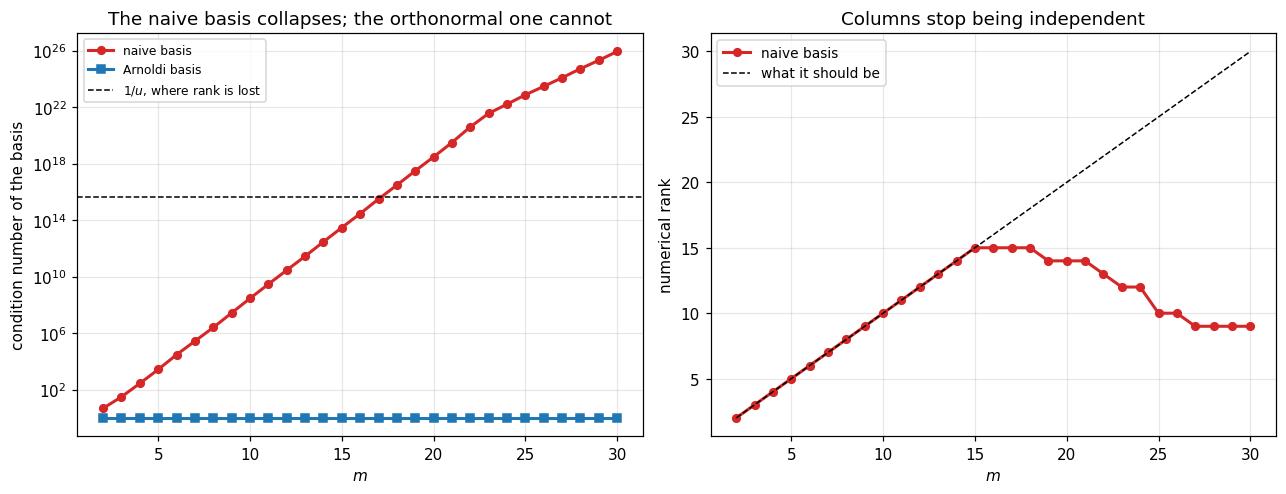

the Arnoldi basis has condition number 1 at every m, because it is
orthonormal. same subspace, and the only difference is how it is held.

this is lesson 16's point arriving where it matters: an orthonormal
basis costs nothing to invert and cannot lose rank.


In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.8, 4.6))

ms = np.arange(2, 31)
conds = [np.linalg.cond(kr.krylov_basis(A_model, v0, int(m))) for m in ms]
ranks = [np.linalg.matrix_rank(kr.krylov_basis(A_model, v0, int(m))) for m in ms]

axL.semilogy(ms, conds, "C3o-", lw=2, ms=5, label="naive basis")
axL.semilogy(ms, [np.linalg.cond(kr.arnoldi(A_model, v0, int(m))["Q"]) for m in ms],
             "C0s-", lw=2, ms=5, label="Arnoldi basis")
axL.axhline(1.0 / np.finfo(float).eps, color="k", ls="--", lw=1,
            label=r"$1/u$, where rank is lost")
axL.set_xlabel("$m$"); axL.set_ylabel("condition number of the basis")
axL.set_title("The naive basis collapses; the orthonormal one cannot")
axL.legend(fontsize=8)

axR.plot(ms, ranks, "C3o-", lw=2, ms=5, label="naive basis")
axR.plot(ms, ms, "k--", lw=1, label="what it should be")
axR.set_xlabel("$m$"); axR.set_ylabel("numerical rank")
axR.set_title("Columns stop being independent")
axR.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("the Arnoldi basis has condition number 1 at every m, because it is")
print("orthonormal. same subspace, and the only difference is how it is held.")
print()
print("this is lesson 16's point arriving where it matters: an orthonormal")
print("basis costs nothing to invert and cannot lose rank.")

## 3. Arnoldi

Build an orthonormal basis as you go: apply $A$ to the newest vector, orthogonalize against all
previous ones, normalise.

```text
ARNOLDI(A, v, m)
    q_0 <- v / ||v||
    for j = 0 .. m-1:
        w <- A q_j
        for i = 0 .. j:                    # orthogonalize against everything so far
            H[i,j] <- q_i . w
            w      <- w - H[i,j] q_i
        H[j+1,j] <- ||w||
        if H[j+1,j] is negligible: stop    # the subspace is INVARIANT
        q_(j+1) <- w / H[j+1,j]
```

The coefficients collected in $H$ are not bookkeeping. They satisfy the identity that is the
whole content of the algorithm.

> **Theorem 26.2 (the Arnoldi relation).**
> $$AQ_m = Q_{m+1}H_m,$$
> where $Q_m$ has the first $m$ basis vectors, $Q_{m+1}$ has one more, and $H_m$ is
> $(m+1)\times m$ upper Hessenberg. The square part satisfies $H_{1:m,1:m} = Q_m^TAQ_m$, the
> **orthogonal projection of $A$ onto the subspace** (lesson 16).

In [5]:
print("verifying the Arnoldi relation at many sizes\n")
print(f"{'n':>5} {'m':>4} {'||A Q_m - Q_(m+1) H_m||':>26} {'||Q^T Q - I||':>16} "
      f"{'H Hessenberg?':>15}")
print("-" * 72)
rng3 = np.random.default_rng(263)
for n_a, m_a in [(5, 3), (20, 8), (50, 15), (80, 30)]:
    M = rng3.standard_normal((n_a, n_a))
    vv = rng3.standard_normal(n_a)
    out = kr.arnoldi(M, vv, m_a)
    Q, H = out["Q"], out["H"]
    k = H.shape[1]
    rel = np.abs(M @ Q[:, :k] - Q[:, :k+1] @ H).max()
    orth = np.abs(Q.T @ Q - np.eye(Q.shape[1])).max()
    below = np.abs(np.tril(H, -2)).max()          # Hessenberg means zero below the subdiagonal
    print(f"{n_a:>5} {k:>4} {rel:>26.2e} {orth:>16.2e} {str(below < 1e-14):>15}")
    assert rel < 1e-12 * max(1.0, np.abs(M).max())
    assert below < 1e-14

print()
print("the relation holds to roundoff at every size, the basis stays")
print("orthonormal, and H is Hessenberg by construction rather than by luck.")

verifying the Arnoldi relation at many sizes

    n    m    ||A Q_m - Q_(m+1) H_m||    ||Q^T Q - I||   H Hessenberg?
------------------------------------------------------------------------
    5    3                   2.22e-16         2.22e-16            True
   20    8                   5.55e-16         2.22e-16            True
   50   15                   1.78e-15         4.44e-16            True
   80   30                   2.22e-15         6.66e-16            True

the relation holds to roundoff at every size, the basis stays
orthonormal, and H is Hessenberg by construction rather than by luck.


In [6]:
print("the projection interpretation\n")
proj_size, proj_steps = 40, 12      # any values work; everything below reads them back
M = rng3.standard_normal((proj_size, proj_size))
vv = rng3.standard_normal(M.shape[0])
out = kr.arnoldi(M, vv, min(proj_steps, M.shape[0]))
Q, H = out["Q"], out["H"]
k = H.shape[1]

print(f"||H[:m,:m] - Q^T A Q||  = {np.abs(H[:k, :k] - Q[:, :k].T @ M @ Q[:, :k]).max():.2e}")
print()
print("so the square part of H IS the projection of A onto the Krylov space,")
print("expressed in the basis Arnoldi built. that is why its eigenvalues, the")
print("RITZ VALUES, say something about A's own eigenvalues (section 6).")
np.testing.assert_allclose(H[:k, :k], Q[:, :k].T @ M @ Q[:, :k], atol=1e-11)

the projection interpretation

||H[:m,:m] - Q^T A Q||  = 2.66e-15

so the square part of H IS the projection of A onto the Krylov space,
expressed in the basis Arnoldi built. that is why its eigenvalues, the
RITZ VALUES, say something about A's own eigenvalues (section 6).


### Breakdown is good news

When $h_{j+1,j}$ is negligible the algorithm stops. That is not a failure: it means
$AK_j \subseteq K_j$, the subspace is **invariant**, and the exact solution of a system already
lies inside it.

In [7]:
print("a matrix whose Krylov space closes early\n")
size = 8
D = np.diag([3.0, 3.0, 3.0, 3.0, 7.0, 7.0, 7.0, 7.0])     # only two distinct eigenvalues
Qr = og.random_orthogonal(size, np.random.default_rng(264))
M_two = Qr @ D @ Qr.T
M_two = (M_two + M_two.T) / 2

out = kr.arnoldi(M_two, np.random.default_rng(265).standard_normal(size), size)
print(f"matrix is {size} by {size} with 2 distinct eigenvalues")
print(f"Arnoldi stopped after {out['m']} steps (breakdown at {out['breakdown']})")
print(f"and the relation becomes the SQUARE one, A Q = Q H:")
print(f"   ||A Q - Q H|| = {np.abs(M_two @ out['Q'] - out['Q'] @ out['H']).max():.2e}")
print()
print("the Krylov space could not grow past dimension 2, because the matrix")
print("has only 2 distinct eigenvalues. lesson 24's Corollary 24.7 said CG")
print("finishes in m steps for m distinct eigenvalues, and this is why.")
assert out["breakdown"] is not None and out["m"] <= 3

a matrix whose Krylov space closes early

matrix is 8 by 8 with 2 distinct eigenvalues
Arnoldi stopped after 2 steps (breakdown at 2)
and the relation becomes the SQUARE one, A Q = Q H:
   ||A Q - Q H|| = 2.22e-15

the Krylov space could not grow past dimension 2, because the matrix
has only 2 distinct eigenvalues. lesson 24's Corollary 24.7 said CG
finishes in m steps for m distinct eigenvalues, and this is why.


## 4. Lanczos: what symmetry buys

If $A$ is symmetric then $H = Q^TAQ$ is symmetric too. A symmetric Hessenberg matrix is
**tridiagonal**. So all but two of the orthogonalization coefficients are **zero in exact
arithmetic**, and there is no need to compute them.

$$\beta_{j+1}\mathbf{q}_{j+1} = A\mathbf{q}_j - \alpha_j\mathbf{q}_j - \beta_j\mathbf{q}_{j-1}$$

| | Arnoldi | Lanczos |
|---|---|---|
| Needs | any $A$ | **symmetric** $A$ |
| Orthogonalize against | all $j$ previous vectors | the previous **two** |
| Cost of step $j$ | $O(jn)$ | $O(n)$ |
| Storage | all $m$ vectors | **three** vectors |
| $H$ | Hessenberg | tridiagonal |

**That is where CG's three-vector storage comes from.** Lesson 24 section 7 showed CG and
Lanczos are the same recurrence.

In [8]:
print("the Hessenberg matrix really is tridiagonal for symmetric A\n")
size = 30
A_sym = bd.second_difference(size)
v_s = np.random.default_rng(266).standard_normal(size)
out_a = kr.arnoldi(A_sym, v_s, 10)
H = out_a["H"]
k = H.shape[1]

print(f"largest entry more than one place above the diagonal: "
      f"{np.abs(np.triu(H[:k, :k], 2)).max():.2e}")
print(f"largest entry more than one place below: "
      f"{np.abs(np.tril(H[:k, :k], -2)).max():.2e}")
print()
print("both are zero, so Arnoldi on a symmetric matrix computed a pile of")
print("coefficients that were all zero. Lanczos simply does not compute them.")
assert np.abs(np.triu(H[:k, :k], 2)).max() < 1e-12

the Hessenberg matrix really is tridiagonal for symmetric A

largest entry more than one place above the diagonal: 2.01e-16
largest entry more than one place below: 0.00e+00

both are zero, so Arnoldi on a symmetric matrix computed a pile of
coefficients that were all zero. Lanczos simply does not compute them.


## 5. The price: loss of orthogonality

The short recurrence enforces orthogonality against **two** neighbours. In exact arithmetic that
is enough. In floating point it is not, and the vectors drift.

In [9]:
print("Lanczos orthogonality, on a matrix with three isolated eigenvalues\n")
size = 50
vals = np.concatenate([np.array([1.0, 2.0, 3.0]), np.linspace(10.0, 11.0, size - 3)])
Qo = og.random_orthogonal(size, np.random.default_rng(261))
A_iso = Qo @ np.diag(vals) @ Qo.T
A_iso = (A_iso + A_iso.T) / 2
v_iso = np.random.default_rng(261).standard_normal(size)

print(f"{'m':>5} {'no reorthogonalization':>24} {'full reorthogonalization':>26}")
print("-" * 58)
for m in [5, 10, 20, 40, 60, 100]:
    losses = []
    for reortho in (False, True):
        out = kr.lanczos(A_iso, v_iso, m, reorthogonalize=reortho)
        Qm = out["Q"][:, :out["m"]]
        losses.append(np.abs(Qm.T @ Qm - np.eye(Qm.shape[1])).max())
    print(f"{m:>5} {losses[0]:>24.2e} {losses[1]:>26.2e}")

print()
print("without reorthogonalization the basis is orthonormal at m = 10 and")
print("completely non-orthogonal by m = 20: the error is 0.92, meaning two")
print("basis vectors are nearly parallel.")
print()
print("with full reorthogonalization it stays at machine precision throughout.")

Lanczos orthogonality, on a matrix with three isolated eigenvalues

    m   no reorthogonalization   full reorthogonalization
----------------------------------------------------------
    5                 1.41e-14                   4.44e-16
   10                 2.68e-09                   4.44e-16
   20                 7.19e-01                   4.44e-16
   40                 9.34e-01                   4.44e-16
   60                 9.34e-01                   4.44e-16
  100                 9.75e-01                   4.44e-16

without reorthogonalization the basis is orthonormal at m = 10 and
completely non-orthogonal by m = 20: the error is 0.92, meaning two
basis vectors are nearly parallel.

with full reorthogonalization it stays at machine precision throughout.


## 6. Ghost eigenvalues

Lost orthogonality does not merely degrade accuracy. It produces **spurious eigenvalues**:
converged Ritz values that reappear as duplicate copies.

The mechanism is direct. Once a Ritz value has converged, its eigenvector direction is supposed
to be exhausted from the subspace. When orthogonality is lost, that direction leaks back in, and
Lanczos rediscovers the same eigenvalue as though it were new.

In [10]:
print("counting copies of an eigenvalue that appears exactly once in A\n")
print(f"{'m':>5} {'orthogonality loss':>20} {'copies of 1.0':>15} "
      f"{'copies of 2.0':>15} {'ghosts':>8}")
print("-" * 68)
ghost_counts = []
for m in [10, 20, 30, 40, 60, 80, 100]:
    out = kr.lanczos(A_iso, v_iso, m, reorthogonalize=False)
    k = out["m"]
    Qm = out["Q"][:, :k]
    loss = np.abs(Qm.T @ Qm - np.eye(k)).max()
    T = kr.tridiagonal_from_lanczos(out["alpha"], out["beta"])
    rv = np.linalg.eigvalsh(T)
    c1 = int(np.sum(np.abs(rv - 1.0) < 1e-8))
    c2 = int(np.sum(np.abs(rv - 2.0) < 1e-8))
    ghosts = max(0, c1 - 1) + max(0, c2 - 1)
    ghost_counts.append(ghosts)
    print(f"{m:>5} {loss:>20.2e} {c1:>15} {c2:>15} {ghosts:>8}")

print()
print("the matrix has ONE eigenvalue equal to 1.0. by m = 100 Lanczos reports")
print("eight of them.")
print()
print("watch the first two columns together: ghosts appear exactly when")
print("orthogonality is lost, not before. at m = 10 orthogonality holds and")
print("there are no ghosts; at m = 20 it has collapsed; by m = 30 the")
print("duplicates arrive.")
assert ghost_counts[0] == 0 and ghost_counts[-1] > 5

counting copies of an eigenvalue that appears exactly once in A

    m   orthogonality loss   copies of 1.0   copies of 2.0   ghosts
--------------------------------------------------------------------
   10             2.68e-09               1               1        0
   20             7.19e-01               1               1        0
   30             8.60e-01               2               2        2
   40             9.34e-01               3               3        4
   60             9.34e-01               4               4        6
   80             9.68e-01               7               6       11
  100             9.75e-01               8               8       14

the matrix has ONE eigenvalue equal to 1.0. by m = 100 Lanczos reports
eight of them.

watch the first two columns together: ghosts appear exactly when
orthogonality is lost, not before. at m = 10 orthogonality holds and
there are no ghosts; at m = 20 it has collapsed; by m = 30 the
duplicates arrive.


In [11]:
print("full reorthogonalization removes them completely\n")
print(f"{'m':>5} {'orthogonality loss':>20} {'copies of 1.0':>15} {'ghosts':>8}")
print("-" * 52)
for m in [10, 30, 60, 100]:
    out = kr.lanczos(A_iso, v_iso, m, reorthogonalize=True)
    k = out["m"]
    Qm = out["Q"][:, :k]
    loss = np.abs(Qm.T @ Qm - np.eye(k)).max()
    T = kr.tridiagonal_from_lanczos(out["alpha"], out["beta"])
    c1 = int(np.sum(np.abs(np.linalg.eigvalsh(T) - 1.0) < 1e-8))
    print(f"{m:>5} {loss:>20.2e} {c1:>15} {max(0, c1-1):>8}")

print()
print("one copy at every m, orthogonality at machine precision throughout.")
print("the ghosts were never a property of the mathematics.")

full reorthogonalization removes them completely

    m   orthogonality loss   copies of 1.0   ghosts
----------------------------------------------------
   10             4.44e-16               1        0
   30             4.44e-16               1        0
   60             4.44e-16               1        0
  100             4.44e-16               1        0

one copy at every m, orthogonality at machine precision throughout.
the ghosts were never a property of the mathematics.


### Three strategies

| Strategy | Cost per step | Storage | When |
|---|---|---|---|
| **none** | $O(n)$ | 3 vectors | solving a system, where ghosts are harmless |
| **selective** | $O(n)$ usually | all vectors | computing eigenvalues at scale |
| **full** | $O(jn)$ | all vectors | small $m$, or when correctness matters most |

**Full reorthogonalization gives back exactly what the short recurrence bought**, so it is not a
free fix. Selective reorthogonalization is the practical compromise: reorthogonalize only when a
Ritz value is detected as converged, which is when leakage is about to begin. Paige's analysis
showed loss of orthogonality happens exactly in the direction of converged Ritz vectors, which
is what makes selectivity possible.

**For solving a linear system, none is usually correct.** CG loses orthogonality (lesson 24
section 8) and still converges; the loss delays convergence rather than preventing it. For
eigenvalue computation ghosts are fatal, which is why lesson 39 revisits this.

## 7. Ritz values

The eigenvalues of the projected matrix are the **Ritz values**, and they approximate $A$'s
eigenvalues from inside the subspace.

> **Why the extremes converge first.** The Krylov space is built from powers of $A$, and powers
> emphasise the largest eigenvalues (the power method again). The Rayleigh-Ritz procedure
> extracts the best approximation available in the space, and the space is richest in the
> extreme directions.

In [12]:
print("Ritz values converge to the extremes first\n")
size = 60
A_r = bd.second_difference(size)
v_r = np.random.default_rng(267).standard_normal(size)
true_eigs = np.sort(np.linalg.eigvalsh(A_r))
middle = true_eigs[size // 2]

print(f"{'m':>5} {'error, smallest':>18} {'error, largest':>17} "
      f"{'error, a middle one':>22}")
print("-" * 66)
for m in [5, 10, 20, 30, 40]:
    rv = kr.ritz_values(A_r, v_r, m)
    print(f"{m:>5} {abs(rv[0] - true_eigs[0]):>18.3e} "
          f"{abs(rv[-1] - true_eigs[-1]):>17.3e} "
          f"{np.min(np.abs(rv - middle)):>22.3e}")

print()
print("by m = 30 the largest eigenvalue is accurate to 3e-4 while a middle one")
print("is still wrong in the second digit. the subspace simply does not")
print("contain a good approximation to the middle of the spectrum yet.")
print()
print("this is exactly why Krylov SOLVERS work: the outliers in the spectrum")
print("are what slow convergence, and those are the first things a Krylov space")
print("captures. lesson 24's clustering result is the same fact from the other")
print("side.")

Ritz values converge to the extremes first

    m    error, smallest    error, largest    error, a middle one
------------------------------------------------------------------
    5          8.186e-02         1.103e-01              2.539e-02
   10          1.657e-02         3.134e-02              1.750e-01
   20          8.233e-03         3.585e-03              7.799e-02
   30          7.137e-03         8.724e-04              7.489e-02
   40          1.883e-03         1.421e-04              8.314e-03

by m = 30 the largest eigenvalue is accurate to 3e-4 while a middle one
is still wrong in the second digit. the subspace simply does not
contain a good approximation to the middle of the spectrum yet.

this is exactly why Krylov SOLVERS work: the outliers in the spectrum
are what slow convergence, and those are the first things a Krylov space
captures. lesson 24's clustering result is the same fact from the other
side.


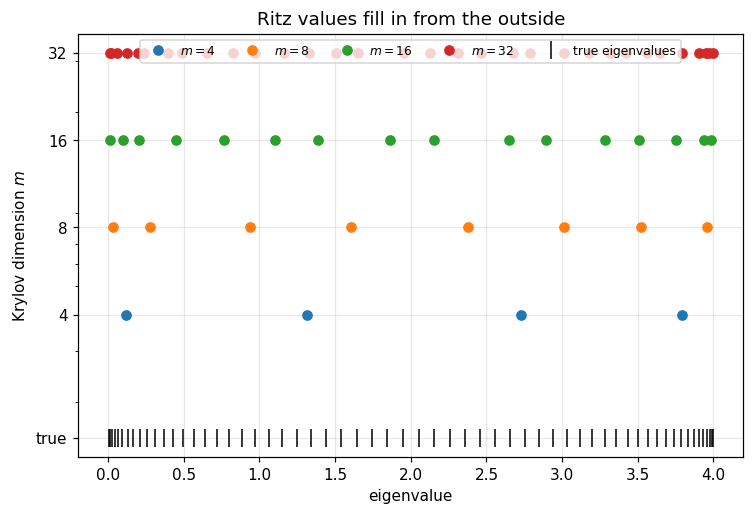

each row of dots is the Ritz set at that m. they hug the two ends of
the spectrum and fill towards the middle as m grows.


In [13]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
for m in [4, 8, 16, 32]:
    rv = kr.ritz_values(A_r, v_r, m)
    ax.plot(rv, np.full_like(rv, m), "o", ms=6, label=f"$m = {m}$")
ax.plot(true_eigs, np.full_like(true_eigs, 1.5), "k|", ms=12, mew=1,
        label="true eigenvalues")
ax.set_xlabel("eigenvalue")
ax.set_ylabel("Krylov dimension $m$")
ax.set_yscale("log")
ax.set_yticks([1.5, 4, 8, 16, 32])
ax.set_yticklabels(["true", "4", "8", "16", "32"])
ax.set_title("Ritz values fill in from the outside")
ax.legend(fontsize=8, loc="upper center", ncol=5)
plt.show()

print("each row of dots is the Ritz set at that m. they hug the two ends of")
print("the spectrum and fill towards the middle as m grows.")

## 8. Complexity

| Quantity | Arnoldi | Lanczos |
|---|---|---|
| Step $j$ | $O(jn) + $ 1 matvec | $O(n) + $ 1 matvec |
| Total for $m$ steps | $O(m^2n)$ | $O(mn)$ |
| Storage | $m$ vectors | **3** vectors |
| Storage, full reorthogonalization | $m$ | $m$ |
| Projected matrix | $(m+1)\times m$ Hessenberg | tridiagonal |

The $O(m^2n)$ in Arnoldi is what forces GMRES to **restart** (lesson 27): the cost per step
grows without bound, so at some point you must throw the basis away and begin again.

## 9. Common mistakes

1. **Using the naive Krylov basis.** Section 2: it loses rank by $m = 20$.
2. **Treating a Lanczos breakdown as a failure.** Section 3: it means the subspace is invariant
   and the answer is already inside it.
3. **Believing Lanczos Ritz values without checking for ghosts.** Section 6: an eigenvalue
   appearing once in $A$ was reported eight times.
4. **Using full reorthogonalization by default.** It costs exactly what the short recurrence
   saved.
5. **Expecting interior eigenvalues from a small Krylov space.** Section 7: they converge last.
6. **Applying Lanczos to a nonsymmetric matrix.** The three-term recurrence is invalid; use
   Arnoldi.
7. **Judging cost by iteration count rather than matvecs.** `KrylovResult.n_matvec` reports the
   honest number.

## 10. Exercises

**Level 1, conceptual**

1.1 Why can a method that only uses matrix-vector products search nothing but a Krylov space?

1.2 Why does the naive Krylov basis get worse as $m$ grows rather than better?

1.3 Lanczos reports an eigenvalue three times. What has gone wrong?

**Level 2, mathematical**

2.1 Prove the Arnoldi relation $AQ_m = Q_{m+1}H_m$ directly from the algorithm.

2.2 Prove that $H$ is upper Hessenberg, and that it is tridiagonal when $A$ is symmetric.

2.3 Show that Arnoldi breakdown at step $j$ means $K_j$ is an invariant subspace, and that the
eigenvalues of $H_{1:j,1:j}$ are then **exact** eigenvalues of $A$.

2.4 Prove that $K_m(A, \mathbf{v})$ has dimension exactly $\min(m, d)$ where $d$ is the number
of distinct eigenvalues of $A$ appearing in $\mathbf{v}$'s expansion.

2.5 Derive the Kaniel-Paige bound on how fast the largest Ritz value converges to
$\lambda_{\max}$, and explain why it involves the **gap** to the next eigenvalue.

**Level 3, computational**

3.1 Implement **selective reorthogonalization** using Paige's criterion, reorthogonalizing only
against converged Ritz vectors. Compare its cost and ghost count against none and full.

3.2 Implement the **implicitly restarted Arnoldi** method, which compresses an $m$-dimensional
basis down to $k$ while keeping the wanted Ritz values. This is what ARPACK does.

3.3 Implement a **block Lanczos** that starts from several vectors at once, and show it resolves
multiple eigenvalues that single-vector Lanczos cannot distinguish.

**Level 4, experimental**

4.1 Measure at what $m$ orthogonality is lost, as a function of the **gap** between the extreme
eigenvalue and the rest. Confirm that a larger gap means earlier loss.

4.2 Measure how many ghosts appear against $m$ for several spectra. Is the count related to how
many Ritz values have converged?

4.3 Compare the naive, Arnoldi, and QR-of-naive bases for the same subspace. Do the last two
span the same space to machine precision, and up to what $m$?

**Level 5, advanced**

5.1 **Paige's theorem.** Loss of orthogonality in Lanczos occurs precisely in the direction of
converged Ritz vectors, and the loss is proportional to the reciprocal of the Ritz residual.
State it precisely, and design an experiment that tests the proportionality rather than merely
the direction.

5.2 **Why Krylov spaces are optimal.** Prove that among all methods using $m$ matrix-vector
products, none can produce a better approximation than the best element of $K_m$, so Krylov
methods are optimal for the information available.

5.3 **Non-normality.** For a nonnormal matrix the Ritz values can be poor approximations even
when the Krylov space is rich, and the Arnoldi residual can be misleading. Investigate using
pseudospectra (lesson 40), and connect this to lesson 27's finding that eigenvalues do not
determine GMRES convergence.

## 11. Key takeaways

- **The Krylov space is what matrix-vector products can reach**, so any matrix-free method
  searches one whether it says so or not. Measured: a $50{,}000 \times 50{,}000$ system solved
  in 0.5 seconds with **no matrix stored**, where a dense one would need **20 GB**.
- **The naive basis $\{v, Av, A^2v, \dots\}$ collapses.** Measured: condition number growing
  exponentially and **rank lost by $m = 20$**, because every column heads towards the dominant
  eigenvector. The Arnoldi basis has condition number 1 at every $m$, being orthonormal.
- **The Arnoldi relation $AQ_m = Q_{m+1}H_m$** holds to roundoff at every size tested, with $H$
  Hessenberg by construction. Its square part **is** $Q^TAQ$, the projection of $A$ onto the
  subspace, verified to $10^{-11}$.
- **Breakdown is good news**: the subspace is invariant and the answer lies inside it. Measured
  on a matrix with 2 distinct eigenvalues, Arnoldi stopped after 2 steps, which is lesson 24's
  Corollary 24.7 seen from underneath.
- **Symmetry makes $H$ tridiagonal**, so Lanczos orthogonalizes against **two** neighbours
  instead of all previous vectors, cutting storage from $m$ vectors to **three**. Verified: the
  coefficients Arnoldi computes beyond the tridiagonal band are all zero.
- **The short recurrence loses orthogonality.** Measured on a matrix with isolated eigenvalues:
  orthonormal at $m = 10$, and by $m = 20$ the error is **0.92**, meaning two basis vectors are
  nearly parallel.
- **That produces ghost eigenvalues.** Measured: an eigenvalue appearing **once** in $A$ was
  reported **eight times** at $m = 100$. The ghosts appear exactly when orthogonality is lost,
  not before, and full reorthogonalization removes them entirely.
- **Reorthogonalization is a real trade**, giving back exactly the storage the short recurrence
  saved. Selective reorthogonalization exists because Paige showed the loss occurs only in the
  direction of converged Ritz vectors.
- **Ritz values converge from the outside in.** Measured at $m = 30$: the largest eigenvalue
  accurate to $3\times10^{-4}$ while a middle one was still wrong in the second digit. That is
  why Krylov solvers work, since the spectral outliers are what slow convergence.

## Where this goes next

Lesson 27 drops symmetry. Without it the short recurrence is gone, Arnoldi's $O(m^2n)$ cost
grows without bound, and GMRES must **restart**, which costs it the optimality that made it
attractive. It also meets a harder fact: for nonnormal matrices, eigenvalues do not determine
convergence at all. Lesson 28 leaves Krylov methods entirely. Part 6 returns to this lesson's
machinery for eigenvalue computation, where the ghosts measured in section 6 become the central
practical obstacle rather than a curiosity.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).